In [34]:
import pandas as pd
import numpy as np
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

# Load the dataset (replace the path with your actual file path)
df = pd.read_csv('/content/sample_data/alzheimers_disease_data.csv')

# Preview the dataset
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [35]:
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [36]:
df = pd.get_dummies(df, drop_first=True)
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']
X.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,21.463532,6.518877,0,0,1.725883,0,0,0,1,0
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,20.613267,7.118696,0,0,2.592424,0,0,0,0,1
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,7.356249,5.895077,0,0,7.119548,0,1,0,1,0
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,13.991127,8.965106,0,1,6.481226,0,0,0,0,0
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,13.517609,6.045039,0,0,0.014691,0,0,1,1,0


In [37]:
y.head()

,Diagnosis
0,0
1,0
2,0
3,0
4,0


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(weights))

## Train XGBoost



In [41]:
from xgboost import XGBClassifier

# Initialize XGBClassifier with scale_pos_weight for handling imbalanced classes
xgb_model = XGBClassifier(scale_pos_weight=class_weights[1], eval_metric='logloss', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Predictions



In [42]:
y_pred = xgb_model.predict(X_test)


## Evaluate Model Performance




In [43]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.9581

Confusion Matrix:
[[267  10]
 [  8 145]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       277
           1       0.94      0.95      0.94       153

    accuracy                           0.96       430
   macro avg       0.95      0.96      0.95       430
weighted avg       0.96      0.96      0.96       430



## Confusion Matrix



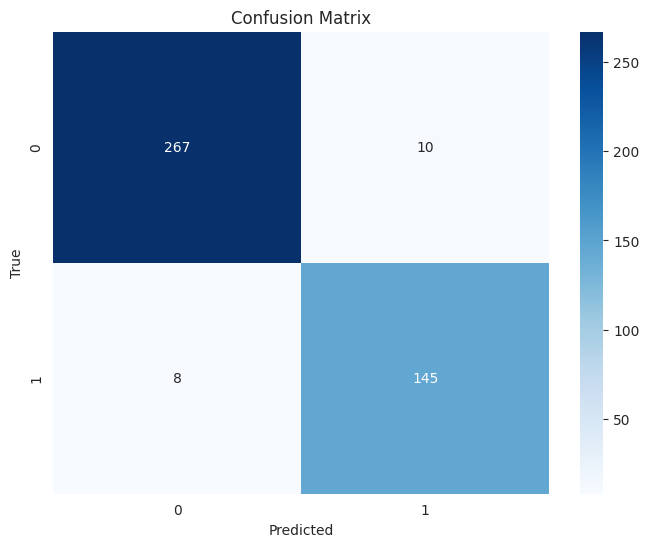

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Classification Report




## Summary:

### Data Analysis Key Findings

*   The trained model achieved an overall accuracy of **0.9581** on the test dataset.
*   The confusion matrix revealed:
    *   **267** True Negatives (correctly predicted Class 0).
    *   **10** False Positives (incorrectly predicted Class 0 as 1).
    *   **8** False Negatives (incorrectly predicted Class 1 as 0).
    *   **145** True Positives (correctly predicted Class 1).
*   The classification report showed strong performance for both classes:
    *   **Class 0**: Precision of 0.97, Recall of 0.96, and an F1-score of 0.97.
    *   **Class 1**: Precision of 0.94, Recall of 0.95, and an F1-score of 0.94.
*   The macro and weighted average F1-scores were both high, around 0.95-0.96, indicating good balance across classes.
*   A heatmap visualization of the confusion matrix provided a clear visual representation of the model's predictive performance.

